In [73]:
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import pandas as pd
from pathlib import Path

# Use LaTeX-like font (Computer Modern)
matplotlib.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "CMU Serif", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.unicode_minus": False,
    "font.size": 12,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
})

In [74]:
# Donnees : les CSV unifies du remetrics. CPC et CMIIC y figurent en deux
# versions (agrum2/agrum3) : on trace celle choisie ici — la comparaison des
# deux versions a son propre notebook (compare_agrum2_agrum3_figures).
CPC_CMIIC_VERSION = "agrum3"

# --- Choose which dataset to plot (change this line) ---
#DATASET = "cbn_unif_mixture"
#DATASET = "cbn_unif_gauss"
#DATASET = "cbn_exp_clayton"
#DATASET = "sem_gaussian"
DATASET = "sem_laplace"

df = pd.read_csv(f"{DATASET}.csv")
df = df[~df.algo.isin(["CPC", "CMIIC"]) | (df.version == CPC_CMIIC_VERSION)]

df10 = df[df.n_vars == 10]
df20 = df[df.n_vars == 20]

In [75]:
GENERATOR_NAME = DATASET
SAVE_DIR = Path(f"new_figures/{DATASET}")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Couleurs fixes : l'ordre historique des figures du rapport (avril),
# le meme que dans ranking.ipynb — independant de l'ordre des CSV.
ALGO_ORDER = ["CPC", "CMIIC", "MIIC", "GHC+BDeu", "NOTEARS", "NOTEARS Disc.", "LiNGAM", "DAGMA"]
ALGO_COLORS = {algo: sns.color_palette()[i] for i, algo in enumerate(ALGO_ORDER)}

# Mapping from column name to (graph_type, metric) for filename
FILENAME_MAP = {
    "time_s": ("time",),
    "SHD": ("cpdags", "shd"),
    "F1-Score": ("cpdags", "f1"),
    "TPR": ("cpdags", "tpr"),
    "SHD_skeleton": ("skeletons", "shd"),
    "F1-Score_skeleton": ("skeletons", "f1"),
    "TPR_skeleton": ("skeletons", "tpr"),
}

def plot_single(data, y, ylabel, n_vars, show_legend=False):
    """Plot a single metric for one n_vars subset and save as PNG."""
    fig, ax = plt.subplots(figsize=(5, 3.5))
    sns.lineplot(
        data=data, x="n_samples", y=y, hue="algo",
        hue_order=ALGO_ORDER, palette=ALGO_COLORS,
        errorbar="se", marker="o", ax=ax,
    )
    ax.set_xlabel("Number of samples")
    ax.set_ylabel(ylabel)
    if show_legend:
        ax.legend(title=None, frameon=True)
    else:
        ax.get_legend().remove()
    fig.tight_layout()
    parts = FILENAME_MAP[y]
    if len(parts) == 1:
        filename = f"{GENERATOR_NAME}_{n_vars}v_{parts[0]}.png"
    else:
        filename = f"{GENERATOR_NAME}_{n_vars}v_{parts[0]}_{parts[1]}.png"
    fig.savefig(SAVE_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()

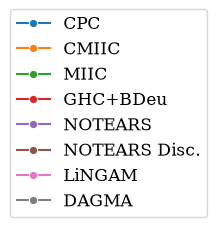

In [76]:
# Plot legend separately
fig_leg, ax_leg = plt.subplots(figsize=(2, 2))
# Draw a dummy lineplot to extract legend handles
sns.lineplot(data=df10, x="n_samples", y="time_s", hue="algo",
             hue_order=ALGO_ORDER, palette=ALGO_COLORS,
             errorbar=None, marker="o", ax=ax_leg)
handles, labels = ax_leg.get_legend_handles_labels()
ax_leg.clear()
ax_leg.axis("off")
fig_leg.legend(handles, labels, loc="center", ncol=1, frameon=True, fontsize=12)
fig_leg.tight_layout()
fig_leg.savefig(SAVE_DIR / f"{GENERATOR_NAME}_legend.png", dpi=600, bbox_inches="tight")
fig_leg.savefig(SAVE_DIR / f"{GENERATOR_NAME}_legend.pdf", bbox_inches="tight")
plt.show()

## 10 variables

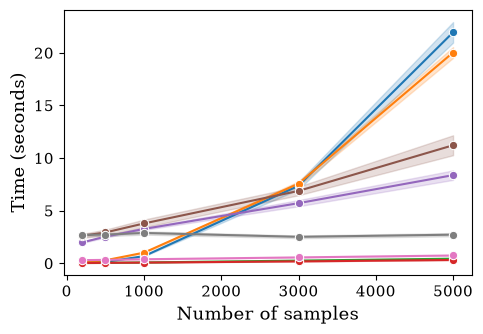

In [77]:
plot_single(df10, "time_s", "Time (seconds)", n_vars=10)

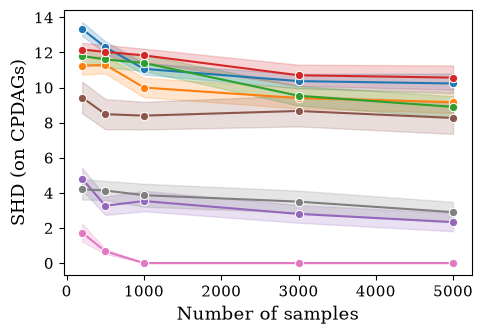

In [78]:
plot_single(df10, "SHD", "SHD (on CPDAGs)", n_vars=10)

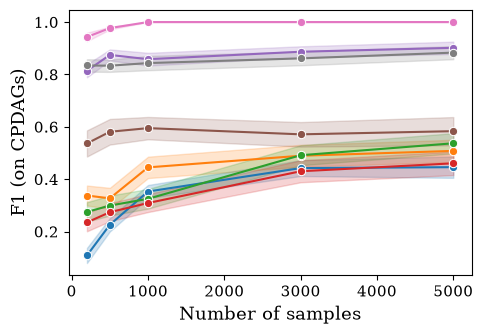

In [79]:
plot_single(df10, "F1-Score", "F1 (on CPDAGs)", n_vars=10)

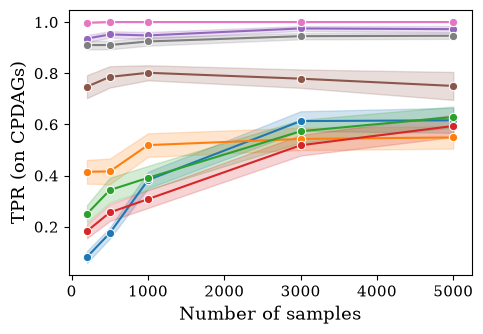

In [80]:
plot_single(df10, "TPR", "TPR (on CPDAGs)", n_vars=10)

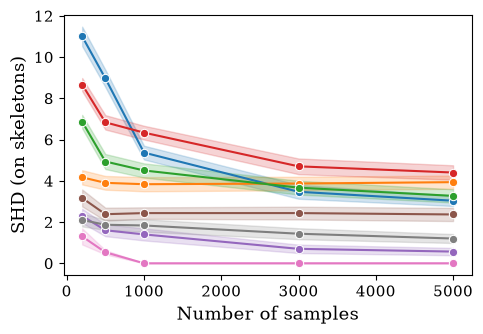

In [81]:
plot_single(df10, "SHD_skeleton", "SHD (on skeletons)", n_vars=10)

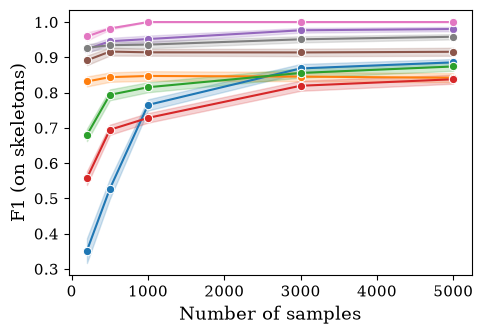

In [82]:
plot_single(df10, "F1-Score_skeleton", "F1 (on skeletons)", n_vars=10)

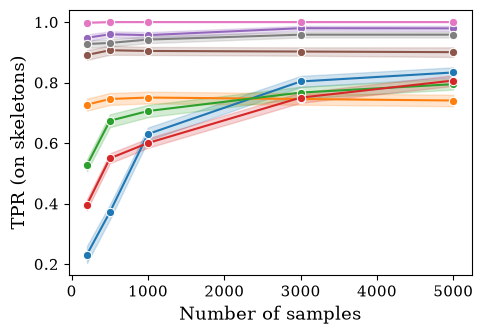

In [83]:
plot_single(df10, "TPR_skeleton", "TPR (on skeletons)", n_vars=10)

## 20 variables

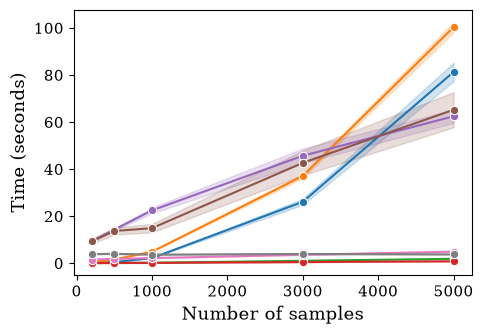

In [84]:
plot_single(df20, "time_s", "Time (seconds)", n_vars=20)

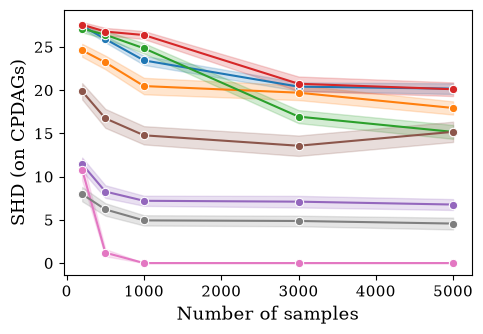

In [85]:
plot_single(df20, "SHD", "SHD (on CPDAGs)", n_vars=20)

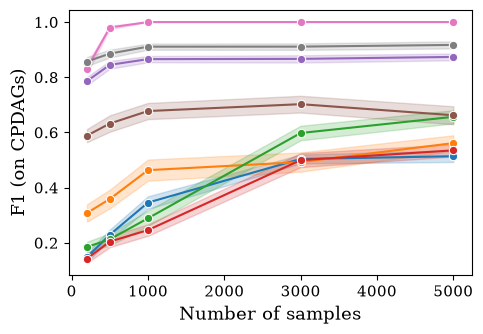

In [86]:
plot_single(df20, "F1-Score", "F1 (on CPDAGs)", n_vars=20)

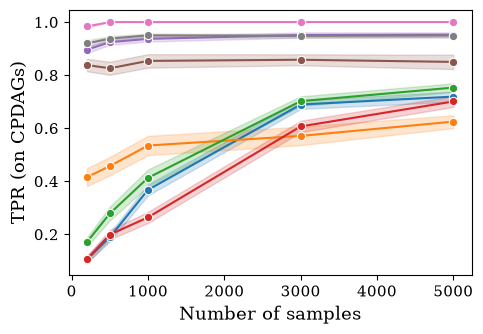

In [87]:
plot_single(df20, "TPR", "TPR (on CPDAGs)", n_vars=20)

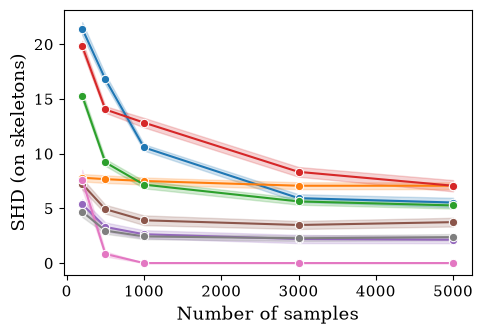

In [88]:
plot_single(df20, "SHD_skeleton", "SHD (on skeletons)", n_vars=20)

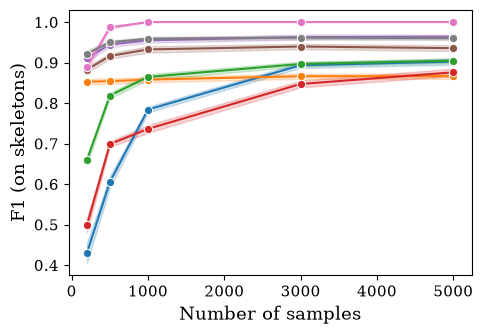

In [89]:
plot_single(df20, "F1-Score_skeleton", "F1 (on skeletons)", n_vars=20)

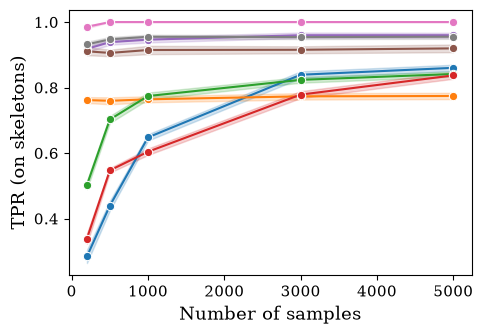

In [90]:
plot_single(df20, "TPR_skeleton", "TPR (on skeletons)", n_vars=20)